# 04 - Classification Model

Bài toán: dự đoán đơn hàng có review xấu (`review_score <= 2`) hay không.

In [1]:
from src.etl.extract import load_olist_tables
from src.etl.transform import build_model_dataset, build_order_features
from src.models.train import train_model

tables = load_olist_tables()
features = build_order_features(tables)
model_dataset = build_model_dataset(features)
model_dataset['bad_review'].value_counts().rename('orders').to_frame()

,orders
bad_review,
0,76028
1,14449


In [2]:
pipeline, metrics = train_model(model_dataset, model_name='random_forest')
pd.DataFrame([{k: v for k, v in metrics.items() if k not in ['classification_report', 'confusion_matrix']}]).T.reset_index().rename(columns={'index': 'metric', 0: 'value'})

,metric,value
0,model_name,random_forest
1,n_train,72381
2,n_test,18096
3,positive_rate,0.159698
4,accuracy,0.88141
5,precision,0.679884
6,recall,0.486505
7,f1,0.567164
8,roc_auc,0.795284


In [3]:
pd.DataFrame(metrics['confusion_matrix'], index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

,Predicted 0,Predicted 1
Actual 0,14544,662
Actual 1,1484,1406


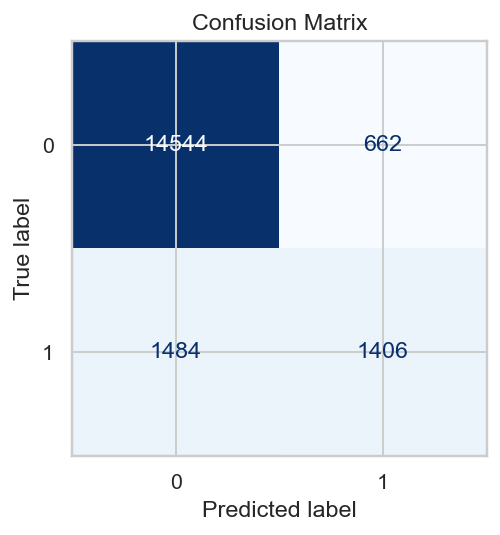

In [4]:
# Trực quan hóa Confusion Matrix
metrics['confusion_matrix']

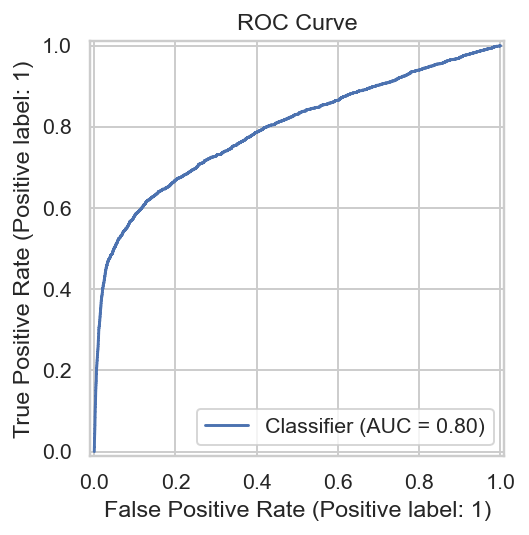

In [5]:
# Trực quan hóa ROC Curve
roc_auc = metrics['roc_auc']

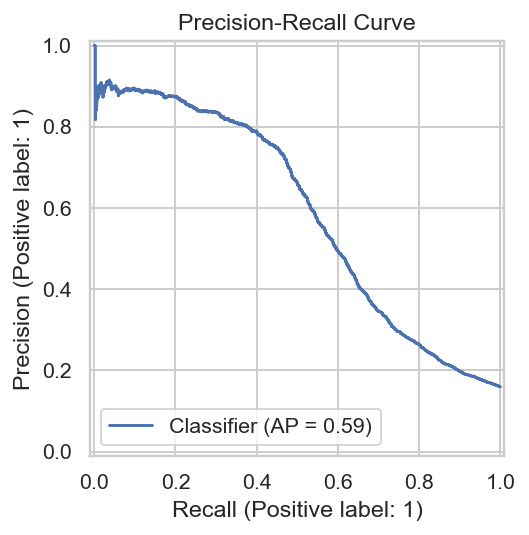

In [6]:
# Trực quan hóa Precision-Recall Curve
model_dataset['bad_review'].mean()

In [7]:
# Bảng top feature importance
feature_importance = fi
feature_importance

,feature,importance
8,num__delay_days,0.175375
7,num__delivery_days,0.146818
12,num__carrier_days,0.082100
9,num__is_delayed,0.068122
1,num__total_freight,0.062314
0,num__total_price,0.057261
2,num__freight_ratio,0.053146
11,num__approval_hours,0.053064
10,num__order_month,0.034318
4,num__item_count,0.032548


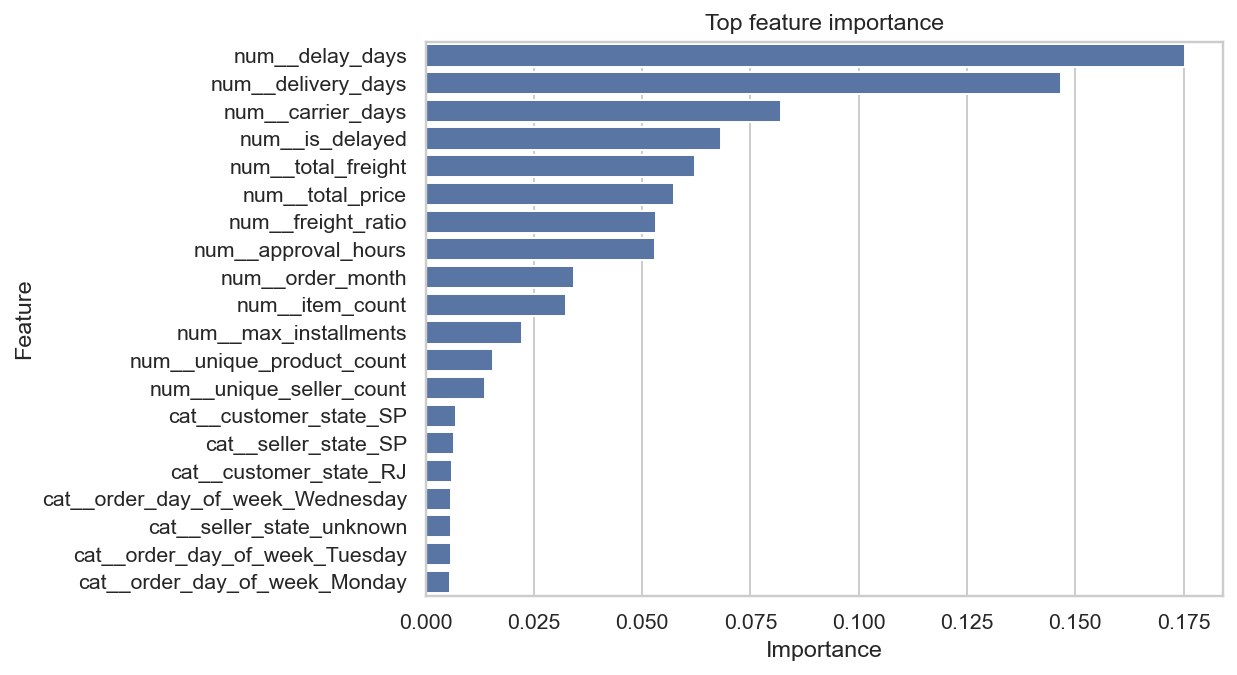

In [8]:
# Biểu đồ feature importance
feature_importance.head(20)